# Churn Analysis and Customer Intelligence


#### by Abhijeet Jagtap (Data Analyst)

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## Import Database


In [2]:
conn = sqlite3.connect("../data/raw/customer_churn.db")

sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table';
"""


tables = pd.read_sql(sql_query, conn)


for table_name in tables["name"]:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")


conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


## Data Cleaning (Customer Data)

In [3]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [4]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [5]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


#### a. Rename column -> Name


In [6]:
df_db_customer.rename(columns={"name": "customer_name"}, inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


#### b. Drop Columns -> Interest & Pincode

In [7]:
# df_db_customer.drop(df_db_customer.columns[-2:] , axis = 1)  #by Indexing

df_db_customer.drop(columns=["interests", "pincode"], inplace=True)

In [8]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [9]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerid     21 non-null     str  
 1   customer_name  21 non-null     str  
 2   country        18 non-null     str  
 3   state          21 non-null     str  
 4   gender         21 non-null     str  
 5   dob            21 non-null     str  
dtypes: str(6)
memory usage: 1.1 KB


#### c. Change data type -> DOB

In [10]:
df_db_customer["dob"] = pd.to_datetime(df_db_customer["dob"])

In [11]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


#### d. Data Standardization -> Gender

In [12]:
df_db_customer["gender"].unique()

<StringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [13]:
df_db_customer["gender"] = df_db_customer["gender"].replace(
    {"Men": "Male", "Women": "Female"}
)

In [14]:
df_db_customer["gender"].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

#### e. Missing Values -> Country

In [15]:
df_db_customer[df_db_customer["country"].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [16]:
df_db_customer[["country", "state"]]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,NaN,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,NaN,Kathmandu
9,Nepal,Kathmandu


In [17]:
# country state unique value pair

state_country_mapping = (
    df_db_customer.dropna(subset=["country"]).set_index("state")["country"].to_dict()
)
state_country_mapping

{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'Nepal',
 'Uttar Pradesh': 'India',
 'Telangana': 'India'}

In [18]:
df_db_customer["country"] = df_db_customer["country"].fillna(
    df_db_customer["state"].map(state_country_mapping)
)

In [19]:
df_db_customer[df_db_customer["country"].isna()]

,customerid,customer_name,country,state,gender,dob


In [20]:
df_db_customer[["country", "state"]]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


## Data Cleaning (Susbcription Data)

In [21]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [22]:
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaN,NaN,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaN,NaN,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaN,NaN,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaN,NaN,13.99,790,47


In [23]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [24]:
date_col = ["subscription_start_date", "renewal_date", "cancellation_date"]

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [25]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


## Data Cleaning (Customer Support)

In [26]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [27]:
df_db_support.tail()

,customerid,complaint_date,escalations,csat_score,col_1,comment
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,NaN
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,NaN
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,NaN
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [28]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [29]:
df_db_support.drop(columns=["col_1", "comment"], inplace=True)

In [30]:
df_db_support["complaint_date"] = pd.to_datetime(df_db_support["complaint_date"])

In [31]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


## Feature Engineering and Data Integration

Steps performed:

- Created churn_flag column for customer retention analysis
- Joined subscription, customer, and support datasets using left joins
- Investigated duplicate records after merging
- Identified duplicate support entries causing row multiplication
- Aggregated support complaints into complaint_count
- Sorted support records and retained the latest customer interaction

In [32]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


#### Create new column using existing column -> Churn Flag

In [33]:
df_db_subscription["churn_flag"] = np.where(
    df_db_subscription["cancellation_date"].notna(), 1, 0
)

In [34]:
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22,0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5,0
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34,0
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,41,0


#### Join tables 


In [35]:
# Has duplicate table, fix them first then perform merge operation

df = df_db_subscription.merge(df_db_customer, on="customerid", how="left").merge(
    df_db_support, on="customerid", how="left"
)

In [36]:
df.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0


In [37]:
df.shape

(23, 20)

In [38]:
df_db_subscription["customerid"].nunique()

21

In [39]:
df_db_customer["customerid"].nunique()

21

In [40]:
df_db_support["customerid"].nunique()

7

In [41]:
df_db_support["customerid"].size

9

In [42]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30


In [43]:
df_db_support["complaint_count"] = df_db_support.groupby("customerid")[
    "customerid"
].transform("count")

In [44]:
df_db_support = df_db_support.sort_values("complaint_date").drop_duplicates(
    "customerid", keep="last"
)

In [45]:
df_db_support["customerid"].size

7

In [46]:
df = df_db_subscription.merge(df_db_customer, on="customerid", how="left").merge(
    df_db_support, on="customerid", how="left"
)

In [47]:
df.shape

(21, 21)

### Export data as CSV

In [48]:
df.to_csv("../data/processed/customer_clean.csv", index=False)

## Data Analysis

#### 1. Churn Rate

In [49]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [50]:
churn_rate = df["churn_flag"].mean() * 100
print("Churn Rate =", round(churn_rate, 2), "%")

Churn Rate = 28.57 %


#### 2. Retention Rate

In [51]:
retention_rate = 100 - churn_rate
print("Retention Rate =", round(retention_rate, 2), "%")

Retention Rate = 71.43 %


#### 3. Churn by Plan Type

In [52]:
churn_by_plan = (
    df.groupby("plan_type")["churn_flag"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="churn_rate_pct")
)

print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


#### 4. Churn by State + sum(Revenue) + count of users


In [53]:
churn_by_state = (
    df.groupby("state")
    .agg(
        churn_rate_pct=("churn_flag", "mean"),
        total_revenue=("monthly_charges", "sum"),
        user_count=("churn_flag", "count"),
    )
    .reset_index()
)

churn_by_state["churn_rate_pct"] = churn_by_state["churn_rate_pct"].mul(100).round(2)

print(churn_by_state)

           state  churn_rate_pct  total_revenue  user_count
0          Delhi           25.00          52.96           4
1      Karnataka          100.00          20.98           2
2      Kathmandu            0.00          20.98           2
3    Maharashtra            0.00          50.97           3
4      Meghalaya           66.67          42.97           3
5       Nagaland            0.00          22.99           1
6      Rajasthan            0.00          36.98           2
7      Telangana           50.00          30.98           2
8  Uttar Pradesh            0.00         115.98           2


#### 4. Churn by Subscription type + sum(Revenue) + count of users


In [54]:
churn_by_subscription = (
    df.groupby("subscription_type")
    .agg(
        churn_rate_pct=("churn_flag", "mean"),
        total_revenue=("monthly_charges", "sum"),
        user_count=("churn_flag", "count"),
    )
    .reset_index()
)

churn_by_subscription["churn_rate_pct"] = (
    churn_by_subscription["churn_rate_pct"].mul(100).round(2)
)

print(churn_by_subscription)

  subscription_type  churn_rate_pct  total_revenue  user_count
0           Organic            0.00         145.91           9
1              Paid           16.67         174.94           6
2          Refferal           83.33          74.94           6


#### 5. ARPU (Average Revenue per User)

In [55]:
arpu = df["monthly_charges"].mean()
print("ARPU =", round(arpu, 2))

ARPU = 18.85


#### 6. Avg customer Tenure

        Count of days user has used our service : Cancellation date else current date

In [56]:
today = pd.Timestamp.today()

df["tenure_days"] = np.where(
    df["cancellation_date"].notna(),
    (df["cancellation_date"] - df["subscription_start_date"]).dt.days,
    (today - df["subscription_start_date"]).dt.days,
)

avg_tenure = df["tenure_days"].mean()
print("Avg Tenure (Days) = ", round(avg_tenure), 0)

Avg Tenure (Days) =  1497 0


#### 7. Revenue ar risk - Revenue Lost

In [57]:
revenue_at_risk = df.loc[df["churn_flag"] == 1, "monthly_charges"].sum()

print("Revenue at Risk ($ in 'K') :", revenue_at_risk)

Revenue at Risk ($ in 'K') : 73.94


#### 8. Escalation Rate

        

In [58]:
escalation_rate = (df["escalations"] == "Y").mean() * 100

print("Escalation Rate :", round(escalation_rate, 2), "%")

Escalation Rate : 19.05 %


#### 9. Average Complaint Rate per User

In [59]:
avg_complaints = df["complaint_count"].sum() / df["customerid"].nunique()

print("Average Complaint Rate Per User :", round(avg_complaints, 2), "%")

Average Complaint Rate Per User : 0.43 %


#### 10. Correlation Escalation v/s Churn

In [60]:
df["escalations"] = np.where(df["escalations"] == "Y", 1, 0)  # Encoding str to int type

corr_df = df[["escalations", "churn_flag"]].dropna()

correlation = corr_df["escalations"].corr(df["churn_flag"])

print("Correlation between Escalation & Churn is :", round(correlation, 2))

Correlation between Escalation & Churn is : 0.77


#### 11. Churn Risk

In [61]:
conditions = [
    (df["churn_score"] < 50),
    (df["churn_score"] >= 50) & (df["churn_score"] < 70),
    (df["churn_score"] >= 70),
]

choices = ["low", "med", "high"]

df["churn_risk"] = np.select(conditions, choices, default="unknown")

In [62]:
df[["churn_risk", "churn_score"]].head()

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88


In [63]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

## Data Vizualization using MATPLOTLIB


In [64]:
df_visual = df.copy()

In [65]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

#### a. Monthly Trend Churn  
        - This is time series KPI

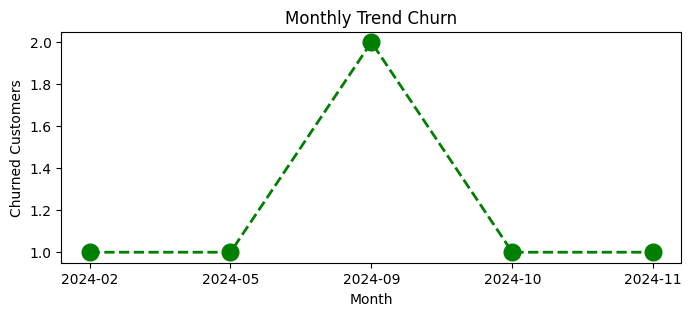

In [66]:
df_visual["cancellation_month"] = df_visual["cancellation_date"].dt.to_period("M")

churn_trend = (
    df_visual[df_visual["churn_flag"] == 1].groupby("cancellation_month").size()
)

plt.figure(figsize=(8, 3))
plt.plot(
    churn_trend.index.astype("str"),
    churn_trend.values,
    color="green",
    marker="o",
    linestyle="dashed",
    linewidth=2,
    markersize=12,
)

plt.title("Monthly Trend Churn")
plt.xlabel("Month")
plt.ylabel("Churned Customers")
plt.show()

#### b. Churned by Plan Type

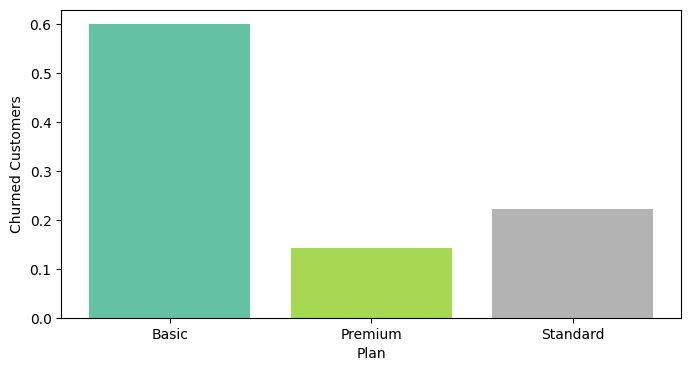

In [67]:
churn_plan = df_visual.groupby("plan_type")["churn_flag"].mean()

# colors = ['lightcoral','bisque','mediumspringgreen']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(8, 4))
plt.bar(churn_plan.index, churn_plan.values, color=colors)

plt.xlabel("Plan")
plt.ylabel("Churned Customers")
plt.show()

#### c. Churn by States

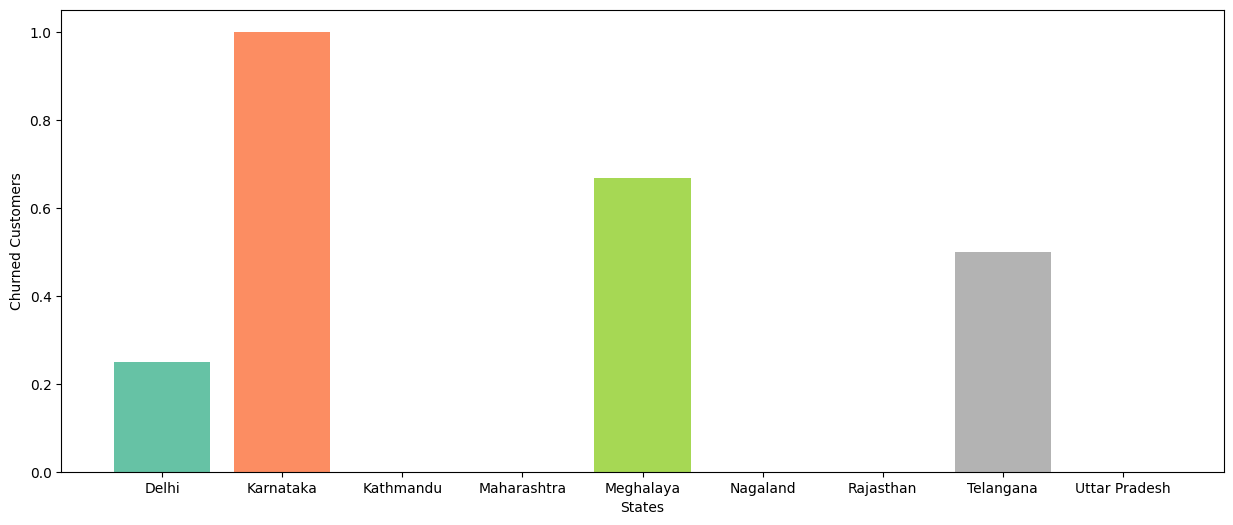

In [68]:
churn_plan = df_visual.groupby("state")["churn_flag"].mean()

# colors = ['lightcoral','bisque','mediumspringgreen']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(15, 6))
plt.bar(churn_plan.index, churn_plan.values, color=colors)

plt.xlabel("States")
plt.ylabel("Churned Customers")
plt.show()

In [69]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1951.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1336.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2626.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


#### d. Churn by Subscription Type


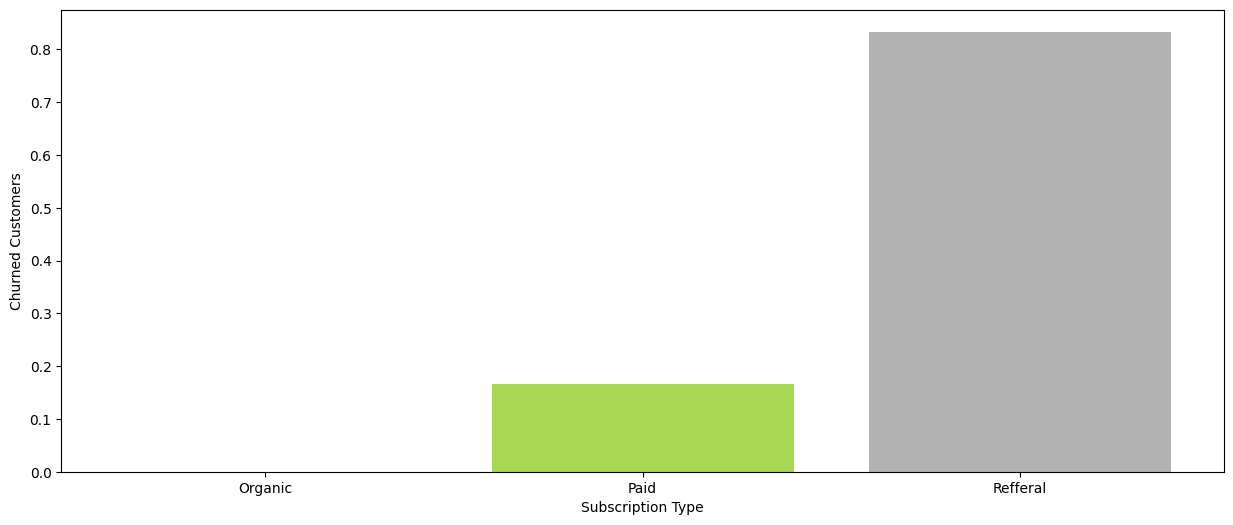

In [70]:
churn_plan = df_visual.groupby("subscription_type")["churn_flag"].mean()

# colors = ['lightcoral','bisque','mediumspringgreen']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(15, 6))
plt.bar(churn_plan.index, churn_plan.values, color=colors)

plt.xlabel("Subscription Type")
plt.ylabel("Churned Customers")
plt.show()

## Data Vizualiaztion using SEABORN

In [71]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [72]:
# df encoded =
df_visual[
    [
        "plan_type",
        "contract_type",
        "churn_score",
        "churn_flag",
        "churn_risk",
        "escalations",
    ]
].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [73]:
df_encoded = df_visual[
    [
        "plan_type",
        "contract_type",
        "churn_score",
        "churn_flag",
        "churn_risk",
        "escalations",
    ]
].head()

categorical_cols = []

#### a. Heatmap (Correlation matrix)

In [ ]:
# remove warnings
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# incorrect method of encoding - as numbers are not assigned based on priority
df_encoded = df_visual[
    [
        "plan_type",
        "contract_type",
        "churn_score",
        "churn_flag",
        "churn_risk",
        "escalations",
    ]
]

categorial_cols = ["plan_type", "contract_type", "churn_risk"]

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype("category").cat.codes

<Axes: >

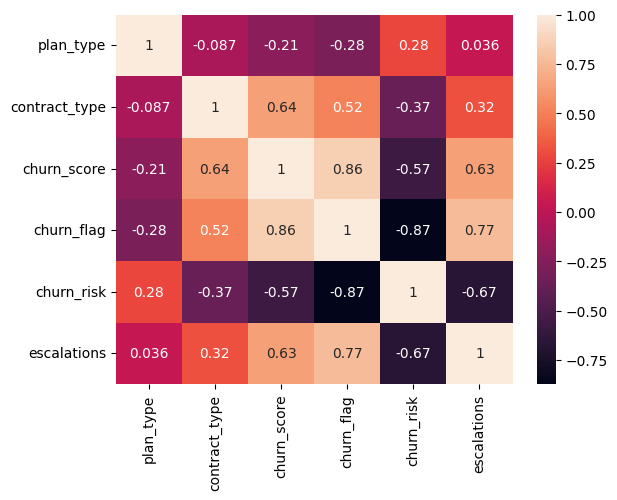

In [78]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

In [ ]:
print("plan_type :", df_visual["plan_type"].unique())
print("contract_type :", df_visual["contract_type"].unique())
print("churn_risk :", df_visual["churn_risk"].unique())

plan_type : <StringArray>
['Standard', 'Premium', 'Basic']
Length: 3, dtype: str
contract_type : <StringArray>
['Annual', 'Monthly']
Length: 2, dtype: str
churn_risk : <StringArray>
['low', 'high', 'med']
Length: 3, dtype: str


In [ ]:
# Correct method of encoding - based on priority
df_encoded = df_visual[
    [
        "plan_type",
        "contract_type",
        "churn_score",
        "churn_flag",
        "churn_risk",
        "escalations",
    ]
]

order_mappings = {
    "plan_type": ["Basic", "Standard", "Premium"],
    "contract_type": ["Monthly", "Annual"],
    "churn_risk": ["low", "med", "high"],
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(
        df_encoded[col].astype("category"), categories=order, ordered=True
    ).codes

In [ ]:
df_visual[
    [
        "plan_type",
        "contract_type",
        "churn_score",
        "churn_flag",
        "churn_risk",
        "escalations",
    ]
].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [83]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

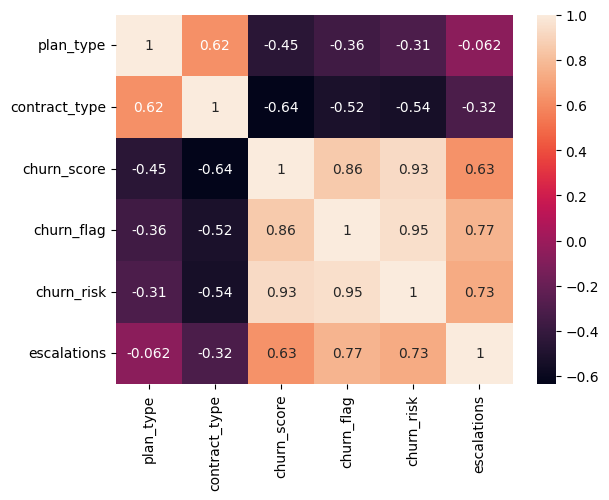

In [84]:
# Heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

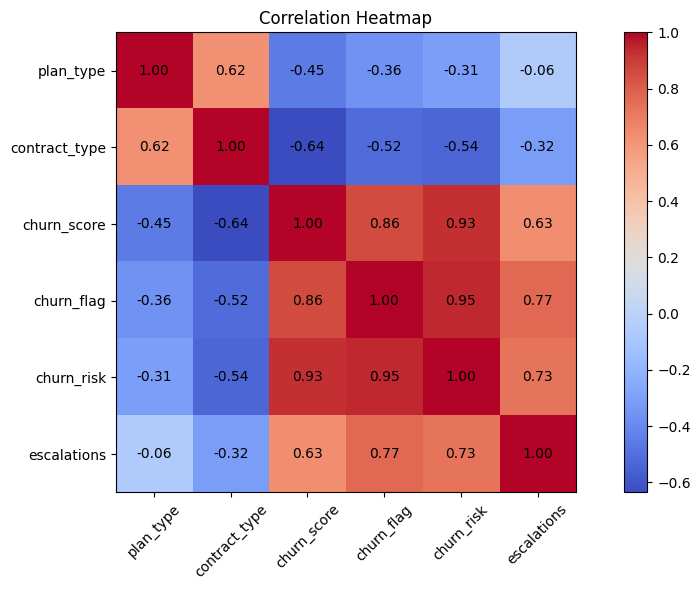

In [ ]:
# Heatmap Using Matplotlib - difficult to plot it

corr_matrix = df_encoded.corr()  # Correlation matrix

fig, ax = plt.subplots(figsize=(10, 6))  # Create figure

cax = ax.imshow(corr_matrix, cmap="coolwarm")  # Heatmap

fig.colorbar(cax)  # Add colorbar

# Axis labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=45)
ax.set_yticklabels(corr_matrix.columns)

# Annotate values inside cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Heatmap")  # Title

plt.tight_layout()
plt.show()

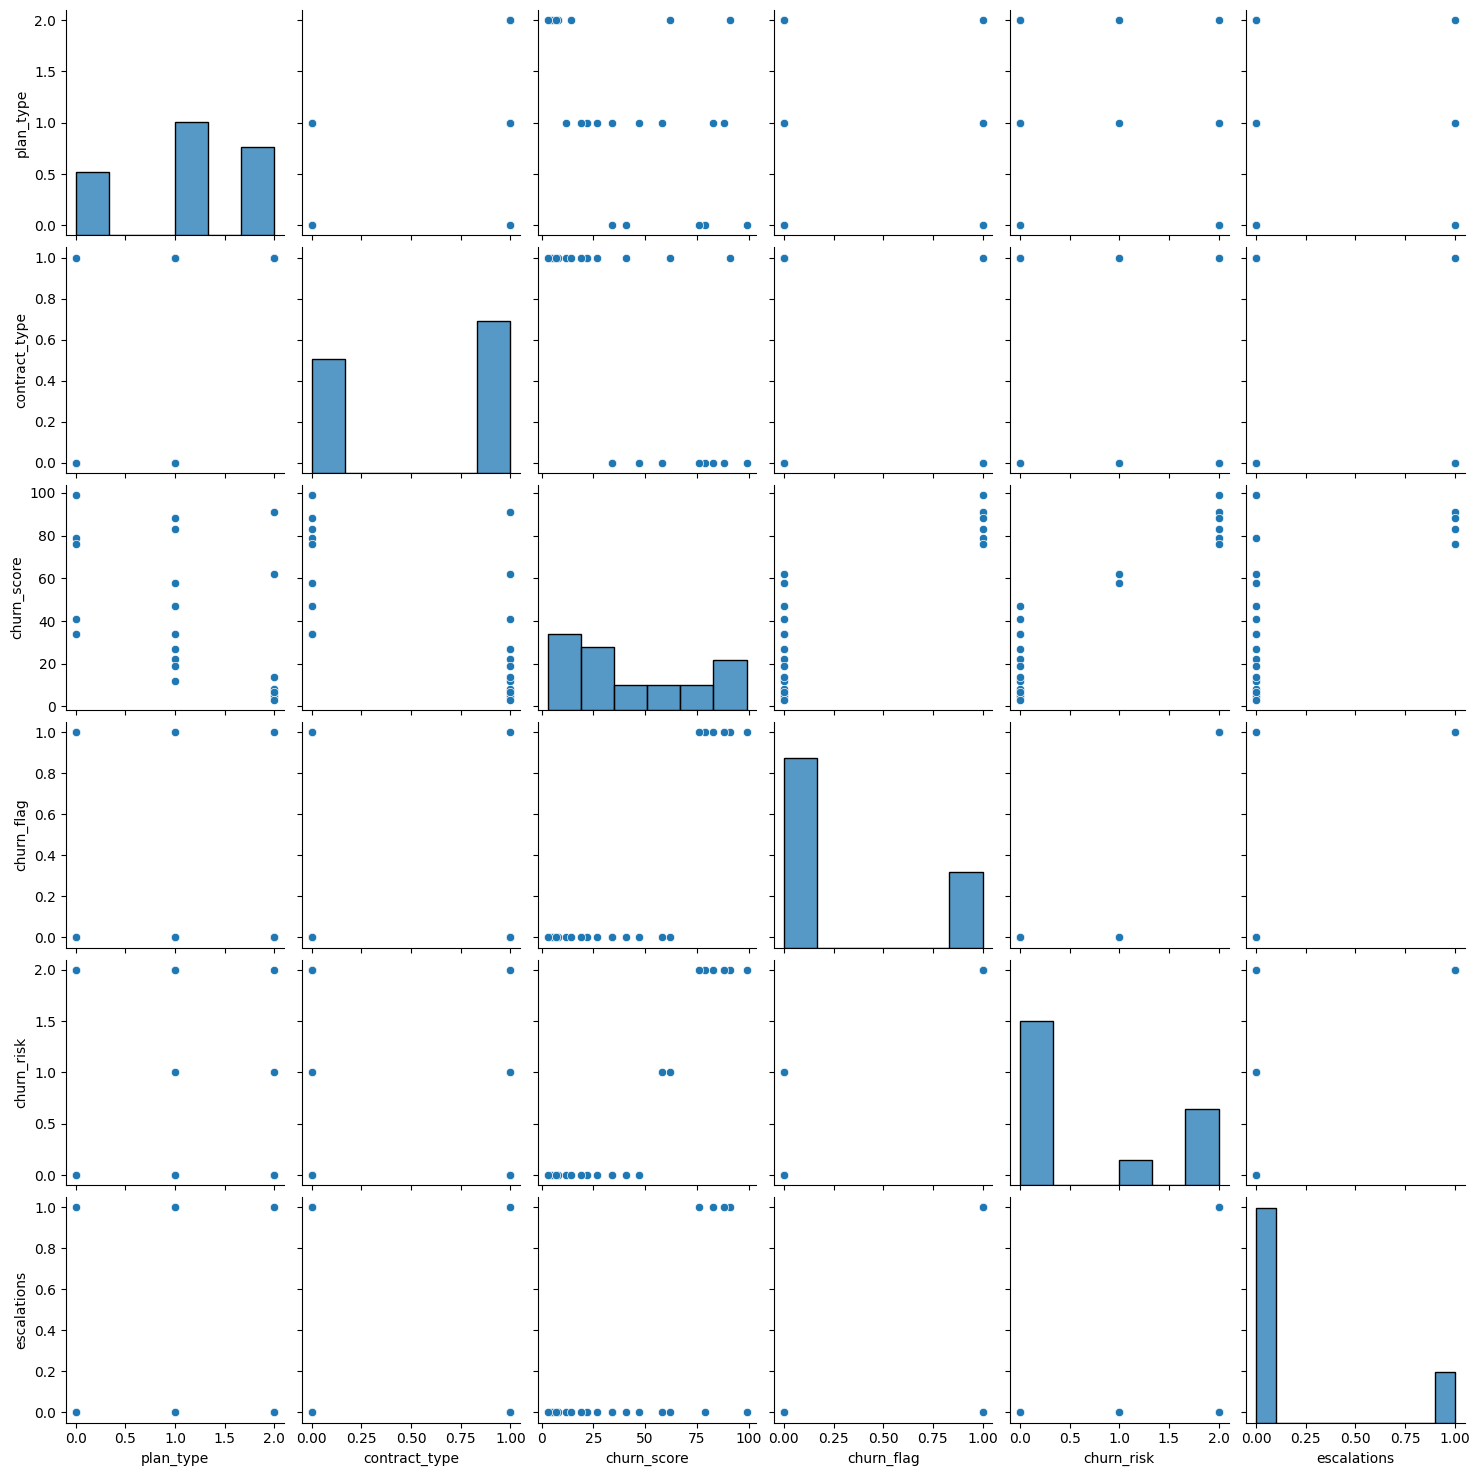

In [86]:
# pairplot - Plot pairwise relationships in a dataset
sns.pairplot(df_encoded)

In [87]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

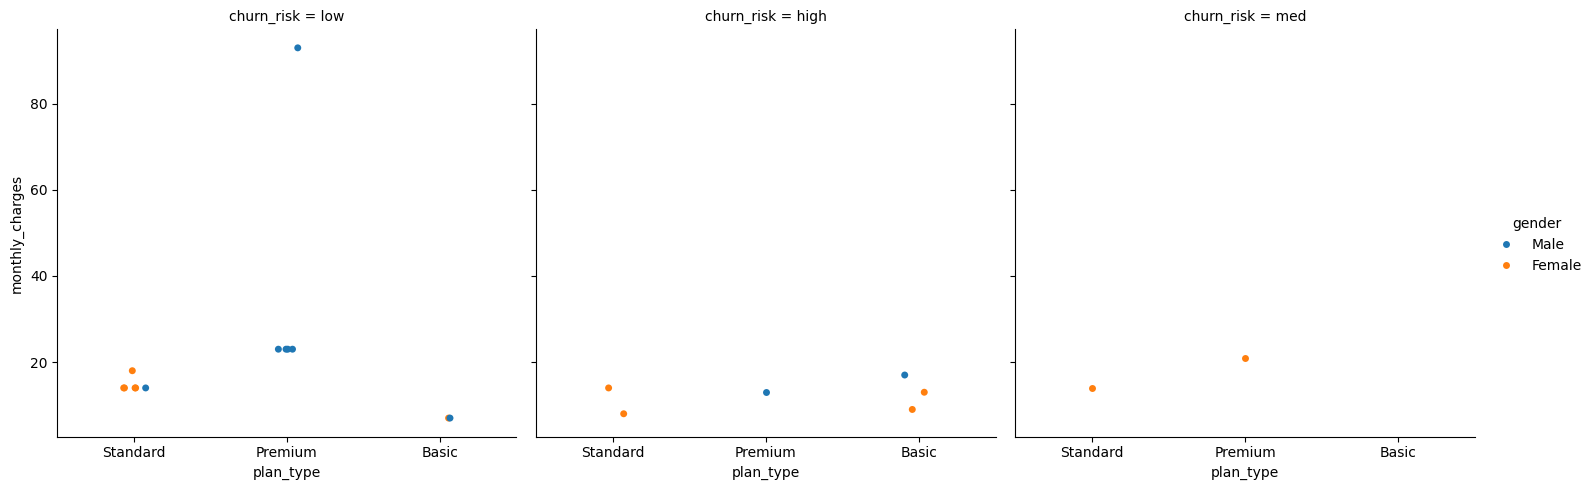

In [ ]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(
    data=df_visual, x="plan_type", y="monthly_charges", hue="gender", col="churn_risk"
)

#### Pivot Table


In [ ]:
# Pivot Table

pd.pivot_table(df_visual, index="plan_type", values="churn_flag", aggfunc="mean")

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [ ]:
# pivot table using multiple cols and agg type

pd.pivot_table(
    df_visual,
    index="plan_type",
    values=["monthly_charges", "customerid", "churn_flag"],
    aggfunc={"monthly_charges": "sum", "customerid": "nunique", "churn_flag": "mean"},
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


# Project Completed :)